In [221]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 결측치 시각화를 위한 라이브러리
import missingno

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습 모델 저장을 위한 라이브러리
import pickle

# 다중공선성 확인을 위햔 라이브러리
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 기타 라이브러리
from scipy.stats import skew
from scipy.stats import norm

In [2]:
train_df = pd.read_csv("C:/Users/이민정/Desktop/부트캠프/파이널프로젝트/전처리/5_잔액정보_segment_병합.csv")

## 다중공선성 확인하기

- 상관계수 0.4 이상의 컬럼 중에서 vif 확인

In [4]:
X = train_df[['잔액_일시불_B0M', '월중평잔_일시불_B0M', '월중평잔_일시불','평잔_일시불_3M','평잔_일시불_6M']]
X = add_constant(X)

In [5]:
vif = pd.DataFrame()
vif["변수"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

             변수        VIF
0         const   1.331652
1    잔액_일시불_B0M  11.463875
2  월중평잔_일시불_B0M  26.447103
3      월중평잔_일시불  25.394005
4     평잔_일시불_3M  18.616740
5     평잔_일시불_6M  11.052343


- 상관계수 0.4 이상의 컬럼 중에서 vif 확인 후 '잔액_일시불_B0M','월중평잔_일시불','평잔_일시불_3M','평잔_일시불_6M' 선택

In [7]:
X1 = train_df[['잔액_일시불_B0M','월중평잔_일시불','평잔_일시불_3M','평잔_일시불_6M']]
X1 = add_constant(X1)

In [8]:
vif1 = pd.DataFrame()
vif1["변수"] = X1.columns
vif1["VIF"] = [variance_inflation_factor(X1.values, i) for i in range(X1.shape[1])]
print(vif1)

           변수        VIF
0       const   1.331651
1  잔액_일시불_B0M   6.726233
2    월중평잔_일시불  17.441487
3   평잔_일시불_3M  18.569224
4   평잔_일시불_6M  10.906464


- 상관계수 0.4 이상의 컬럼 중에서 vif 확인 후 '잔액_일시불_B0M','월중평잔_일시불','평잔_일시불_6M' 선택

In [10]:
X2 = train_df[['잔액_일시불_B0M','월중평잔_일시불','평잔_일시불_6M']]
X2 = add_constant(X2)

In [11]:
vif2 = pd.DataFrame()
vif2["변수"] = X2.columns
vif2["VIF"] = [variance_inflation_factor(X2.values, i) for i in range(X2.shape[1])]
print(vif2)

           변수        VIF
0       const   1.331643
1  잔액_일시불_B0M   6.647221
2    월중평잔_일시불  11.142465
3   평잔_일시불_6M   6.806874


- 상관계수 0.4 이상의 컬럼 중에서 vif 확인 후 '잔액_일시불_B0M','평잔_일시불_6M' 선택

In [13]:
X3 = train_df[['잔액_일시불_B0M','평잔_일시불_6M']]
X3 = add_constant(X3)

In [14]:
vif3 = pd.DataFrame()
vif3["변수"] = X3.columns
vif3["VIF"] = [variance_inflation_factor(X3.values, i) for i in range(X3.shape[1])]
print(vif3)

           변수       VIF
0       const  1.330444
1  잔액_일시불_B0M  4.009327
2   평잔_일시불_6M  4.009327


- 잔액_일시불_B0M, 평잔_일시불_6M끼리의 다중공선성 확인 시 5 미만으로 확인
- 어느정도 다중공선성이 해소 되었다 생각 할 수 있다.

# 잔액_일시불_B0M, 평잔_일시불_6M을 EDA

## 잔액_일시불_B0M EDA

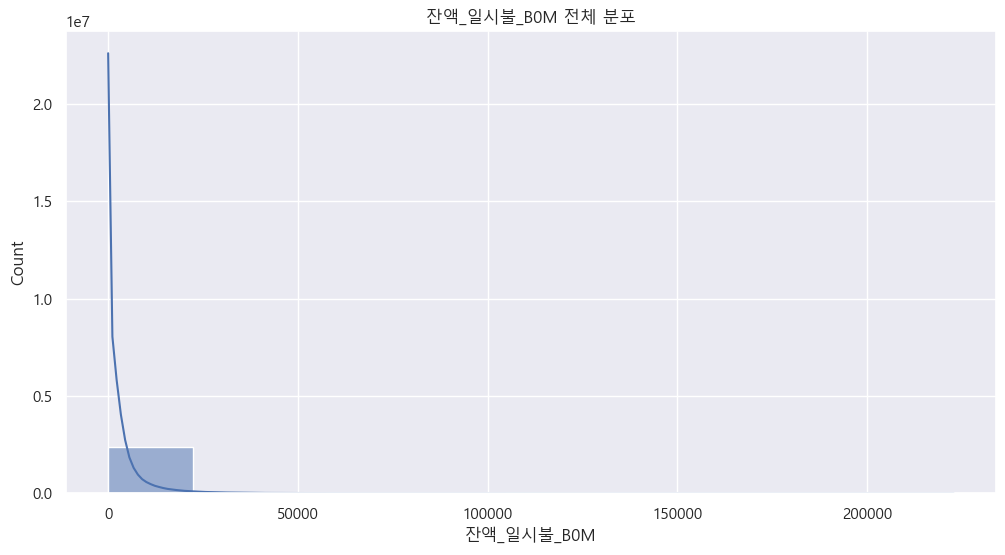

In [18]:
sns.histplot(train_df['잔액_일시불_B0M'], bins=10, kde=True)
plt.title('잔액_일시불_B0M 전체 분포')
plt.show()

- 꼬리가 오른쪽으로 긴 그래프 임을 확인 할 수 있다.
- 평균 > 중앙값 > 최빈값일 것으로 추측가능하다. 
- 데이터의 대부분이 작은 값에 몰려 있고, 큰 값들이 소수 존재하여 오른쪽 꼬리를 형성
- 극단적인 이상치가 존재할 가능성이 크다고 볼 수 있다. 
- 극단적으로 큰 값들이 평균을 끌어올린다고 판단 할 수 있다.

In [19]:
Q1 = train_df['잔액_일시불_B0M'].quantile(0.25)
Q3 = train_df['잔액_일시불_B0M'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"IQR 기준 이상치 경계: {lower} ~ {upper}")
print(f"이상치 수: {(train_df['잔액_일시불_B0M'] > upper).sum()}")

IQR 기준 이상치 경계: -5667.0 ~ 9445.0
이상치 수: 200982


- 예상한 바와 같이 이상치의 수가 많은 것을 확인 할 수 있다.
- 이상치 경계의 lower가 마이너스인 것으로 보아 잘못된 데이터가 들어있을 수 있는 점을 고려해보아야 한다.
- 잘못된 데이터가 들어있지 않다면 0에 가까운 데이터가 굉장히 많을 것으로 예상 할 수 있다.

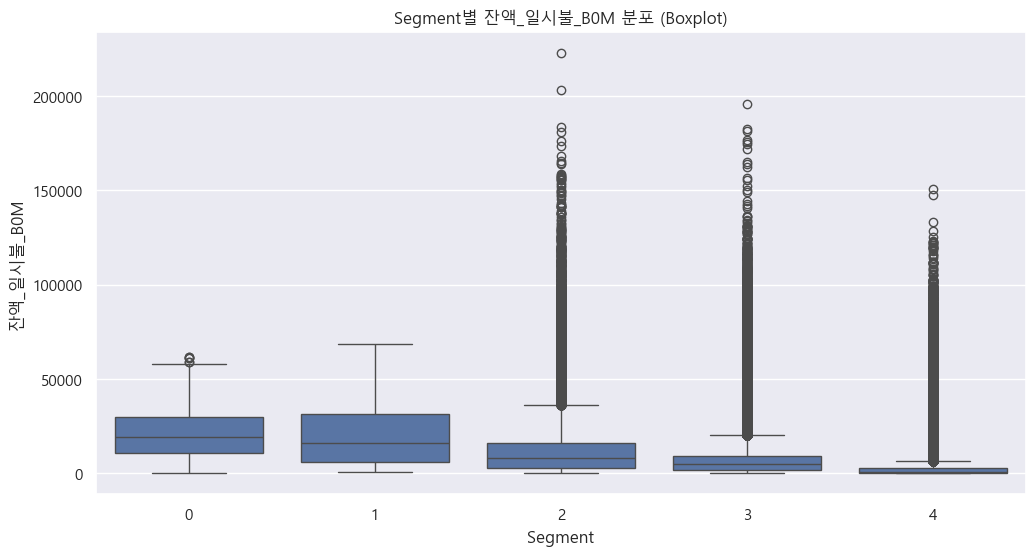

In [20]:
sns.boxplot(data=train_df, x='Segment', y='잔액_일시불_B0M')
plt.title('Segment별 잔액_일시불_B0M 분포 (Boxplot)')
plt.show()

- 이상치가 0에는 조금만 분포하고 있고 2,3,4는 많이 분포하고있다. 1은 이상치가 없다.
- 0과 1에 비하여 2,3,4는 박스의 크기가 현저히 작다.

In [22]:
train_df.groupby('Segment')['잔액_일시불_B0M'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).reset_index()

,Segment,count,mean,median,std,min,max
0,0,972,20699.614198,19025.0,13245.460706,0,61480
1,1,144,19377.381944,15890.5,15524.948205,854,68429
2,2,127590,11505.366870,8019.5,12500.461422,0,222767
3,3,349242,7208.856063,4760.0,9193.192008,0,196046
4,4,1922052,2039.213382,802.0,4092.610674,0,150595


- 평균을 보면 0>1>2>3>4 순이다.
- 중앙값 역시 0>1>2>3>4 순이다.
- 표준편차가 매우 크며, 평균에 비하여 최대값이 매우 크다
- 값이 4에 몰려있는 것을 확인 할 수 있다.
- 2,3,4등급의 경우 최대값이 0,1등급에 비하여 3배 가까이 혹은 그 이상 높다.

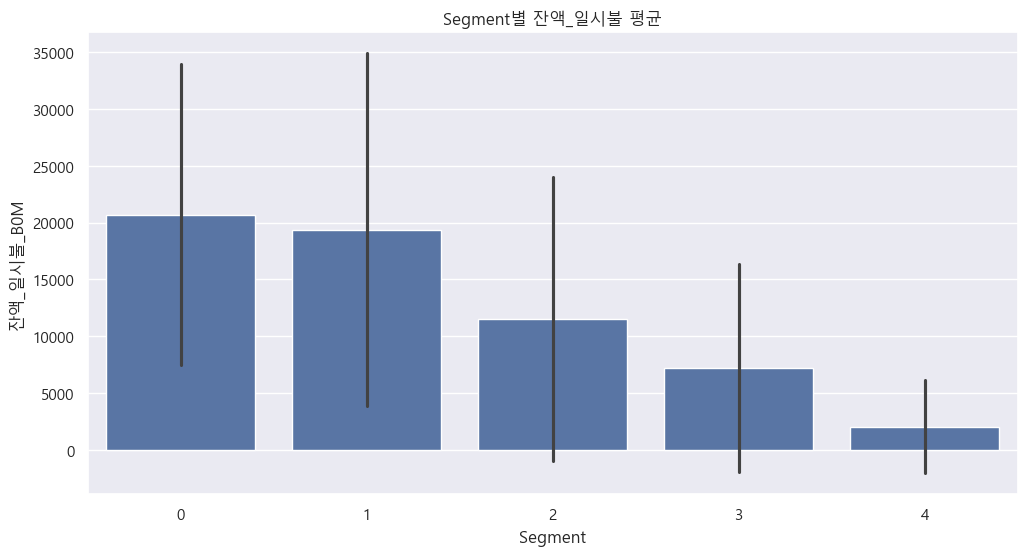

In [24]:
sns.barplot(x='Segment', y='잔액_일시불_B0M', data=train_df, estimator='mean', ci='sd')
plt.title('Segment별 잔액_일시불 평균')
plt.show()

신뢰구간이 막대에 비하여 비정상적으로 크다:
- 표본의 변동성이 크다고 할 수 있다. 따라서 같은 범주 내 값들이 서로 크게 다르다고 판단 할 수 있다.
- 평균이 통계적으로 유의미하지 않을 가능성이 높으며 평균을 신뢰하기 어렵다고 판단 할 수 있다.
- 2,3,4의 경우 신뢰구간이 막대보다 더 밑까지 있는데 이것은 신뢰구간의 하한이 평균보다 훨씬 더 낮다고 생각할 수 있다.

결론적으로 2,3,4는 0,1에 비하여 평균의 신뢰도가 매우 낮으며 데이터가 매우 퍼져 있다

In [25]:
from scipy.stats import f_oneway

groups = [group['잔액_일시불_B0M'].dropna().values for name, group in train_df.groupby('Segment')]
f_stat, p_val = f_oneway(*groups)

print(f"F-통계량: {f_stat:.2f}, p-value: {format(p_val, '.16e')}")

F-통계량: 126911.89, p-value: 0.0000000000000000e+00


- p-value 가 0인것으로 보아 해당 컬럼은 Segment를 예측하기에 적합한 데이터로 판단된다. 
- 다만 이상치에 대한 분석을 해보는 것이 좋을것으로 판단된다.  

## 평잔_일시불_6M EDA

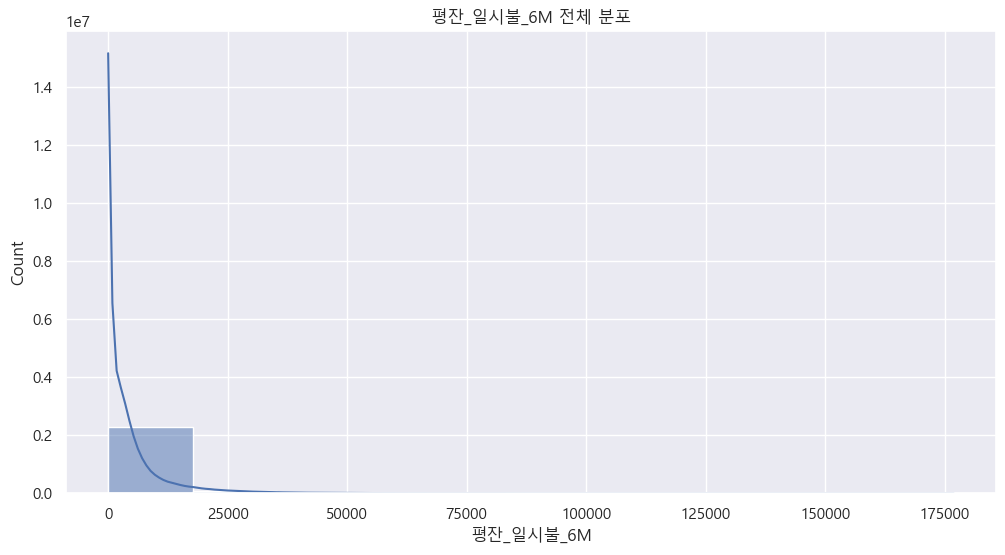

In [27]:
sns.histplot(train_df['평잔_일시불_6M'], bins=10, kde=True)
plt.title('평잔_일시불_6M 전체 분포')
plt.show()

- 꼬리가 오른쪽으로 긴 그래프 임을 확인 할 수 있다.
- 평균 > 중앙값 > 최빈값일 것으로 추측가능하다. 
- 데이터의 대부분이 작은 값에 몰려 있고, 큰 값들이 소수 존재하여 오른쪽 꼬리를 형성
- 극단적인 이상치가 존재할 가능성이 크다고 볼 수 있다. 
- 극단적으로 큰 값들이 평균을 끌어올린다고 판단 할 수 있다.

In [261]:
Q1 = train_df['평잔_일시불_6M'].quantile(0.25)
Q3 = train_df['평잔_일시불_6M'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"IQR 기준 이상치 경계: {lower} ~ {upper}")
print(f"이상치 수: {(train_df['평잔_일시불_6M'] > upper).sum()}")

IQR 기준 이상치 경계: -7281.5 ~ 12418.5
이상치 수: 203731


- 예상한 바와 같이 이상치의 수가 많은 것을 확인 할 수 있다.
- 이상치 경계의 lower가 마이너스인 것으로 보아 잘못된 데이터가 들어있을 수 있는 점을 고려해보아야 한다.
- 잘못된 데이터가 들어있지 않다면 0에 가까운 데이터가 굉장히 많을 것으로 예상 할 수 있다.  

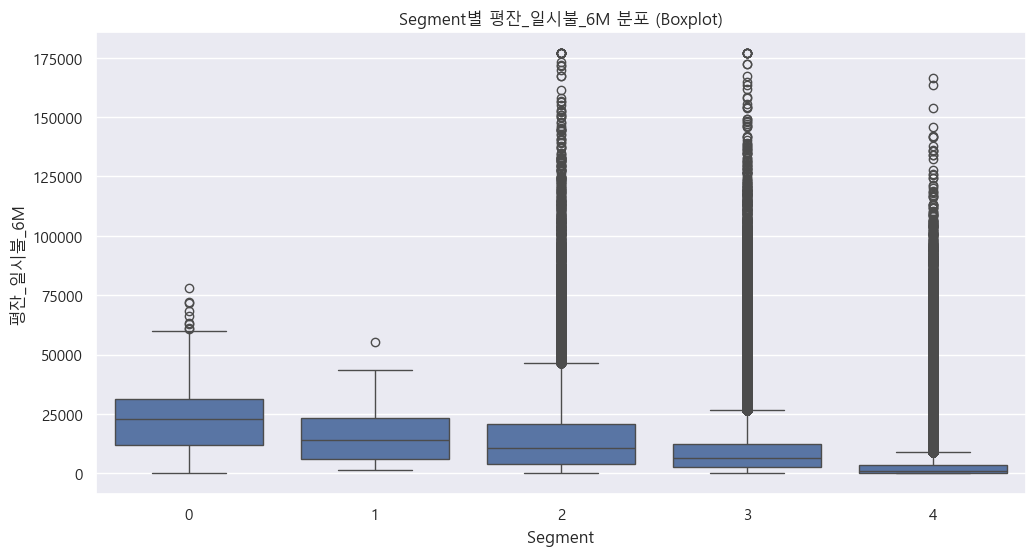

In [29]:
sns.boxplot(data=train_df, x='Segment', y='평잔_일시불_6M')
plt.title('Segment별 평잔_일시불_6M 분포 (Boxplot)')
plt.show()

- 이상치가 0과 1은 조금만 분포하고 있고 2,3,4는 많이 분포하고있다.
- 또한 4로 갈수록 박스의 크기가 작아지고 있으며 평균이 낮아지고 있다는 것을 확인 할 수 있다. 

In [31]:
train_df.groupby('Segment')['평잔_일시불_6M'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).reset_index()

,Segment,count,mean,median,std,min,max
0,0,972,23138.444444,22736.0,14039.852518,29,77858
1,1,144,16162.847222,13796.0,11732.966144,1293,55337
2,2,127590,14118.216788,10689.0,13557.286300,0,176861
3,3,349242,9045.806925,6376.0,9996.733316,0,176861
4,4,1922052,2640.088545,985.0,4766.977045,0,166448


- 표준편차가 매우 크며, 평균에 비하여 최대값이 매우 크다
- 값이 4에 몰려있는 것을 확인 할 수 있다.
- 2,3,4등급의 경우 최대값이 0,1등급에 비하여 2배 이상 높다.

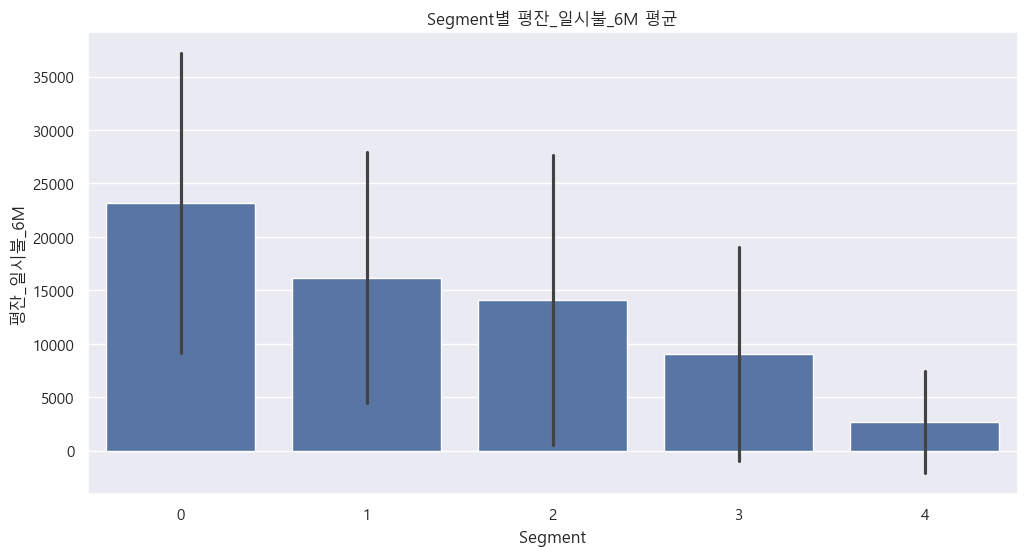

In [32]:
sns.barplot(x='Segment', y='평잔_일시불_6M', data=train_df, estimator='mean', ci='sd')
plt.title('Segment별 평잔_일시불_6M 평균')
plt.show()

신뢰구간이 막대에 비하여 비정상적으로 크다:
- 표본의 변동성이 크다고 할 수 있다. 따라서 같은 범주 내 값들이 서로 크게 다르다고 판단 할 수 있다.
- 평균이 통계적으로 유의미하지 않을 가능성이 높으며 평균을 신뢰하기 어렵다고 판단 할 수 있다.
- 3,4의 경우 신뢰구간이 막대보다 더 밑까지 있는데 이것은 신뢰구간의 하한이 평균보다 훨씬 더 낮다고 생각할 수 있다.

결론적으로 2,3,4는 0,1에 비하여 평균의 신뢰도가 매우 낮으며 데이터가 매우 퍼져 있다

In [34]:
groups = [group['평잔_일시불_6M'].dropna().values for name, group in train_df.groupby('Segment')]
f_stat, p_val = f_oneway(*groups)

print(f"F-통계량: {f_stat:.2f}, p-value: {p_val:.4f}")

F-통계량: 151396.54, p-value: 0.0000


- p-value 가 0인것으로 보아 해당 컬럼은 Segment를 예측하기에 적합한 데이터로 판단된다. 
- 다만 이상치에 대한 분석을 해보는 것이 좋을것으로 판단된다.  

## Segment 등급별 EDA

### A등급

Segment A 기술통계
       잔액_일시불_B0M  평잔_일시불_6M
count      972.00     972.00
mean     20699.61   23138.44
std      13245.46   14039.85
min          0.00      29.00
25%      10570.25   11973.00
50%      19025.00   22736.00
75%      29807.50   31441.00
max      61480.00   77858.00


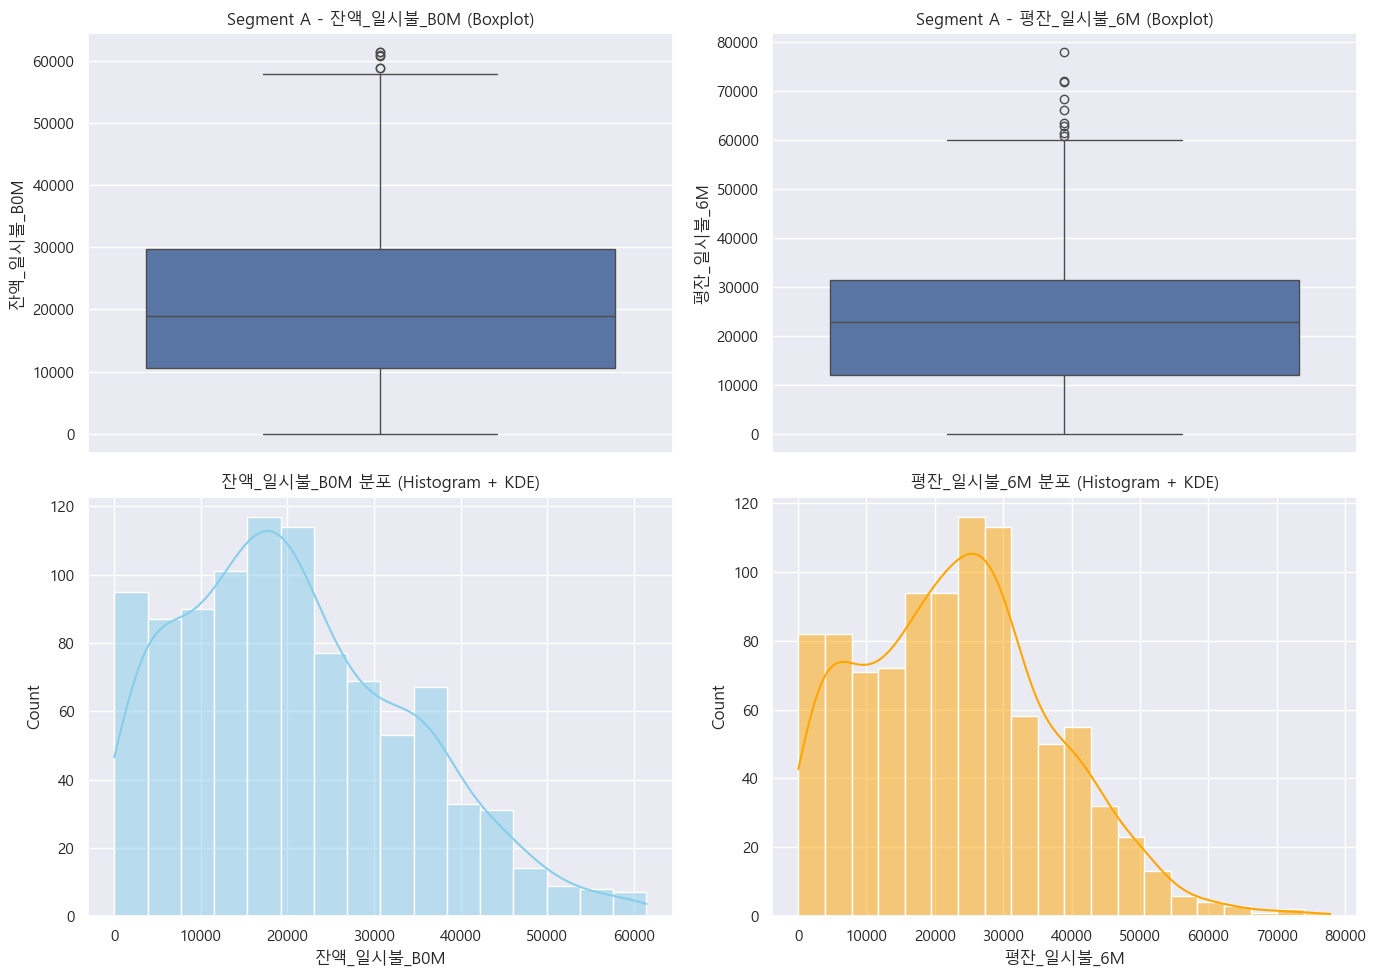

In [165]:
segA = train_df[train_df['Segment'] == 0]
cols = ['잔액_일시불_B0M', '평잔_일시불_6M']

print("Segment A 기술통계")
print(segA[cols].describe().round(2))

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

sns.boxplot(data=segA, y='잔액_일시불_B0M', ax=axes[0, 0])
axes[0, 0].set_title('Segment A - 잔액_일시불_B0M (Boxplot)')

sns.boxplot(data=segA, y='평잔_일시불_6M', ax=axes[0, 1])
axes[0, 1].set_title('Segment A - 평잔_일시불_6M (Boxplot)')

sns.histplot(segA['잔액_일시불_B0M'], kde=True, color='skyblue', ax=axes[1, 0])
axes[1, 0].set_title('잔액_일시불_B0M 분포 (Histogram + KDE)')

sns.histplot(segA['평잔_일시불_6M'], kde=True, color='orange', ax=axes[1, 1])
axes[1, 1].set_title('평잔_일시불_6M 분포 (Histogram + KDE)')

plt.tight_layout()
plt.show()

- 두 변수 모두 평균과 중앙값{(잔액일시불 : 20699, 19025),(평잔일시불 : 23138, 22736 )}이 비슷하며, 다른 등급에 비해 극단적으로 치우치지는 않은 분포
- 표준편차가 크고, 최대값이 평균의 2~3배 수준이라 일부 고액 데이터가 존재한다고 볼 수 있다.

잔액_일시불_B0M:
- 이상치가 60,000대 부근에 일부 존재
- 중간 50%가 대략 15,000 ~ 40,000 사이
- 분포가 오른쪽으로 꼬리가 긴형태
- 전체적으로 20,000 전후 구간에 데이터가 집중
- 일부 고액 사용자가 존재함

평잔_일시불_6M
- 이상치가 더 많이 존재함
- 중간값은 비슷하지만, 상단이 조금 더 넓게 퍼져 있음
- 분포가 조금 더 완만하며, 역시 오른쪽 꼬리가 긴 형태
- 잔액일시불보다 분포가 더 퍼져 있고, 이상치가 더 뚜렷하다.

### B등급

Segment B 기술통계
       잔액_일시불_B0M  평잔_일시불_6M
count      144.00     144.00
mean     19377.38   16162.85
std      15524.95   11732.97
min        854.00    1293.00
25%       6112.75    6009.50
50%      15890.50   13796.00
75%      31177.50   23335.50
max      68429.00   55337.00


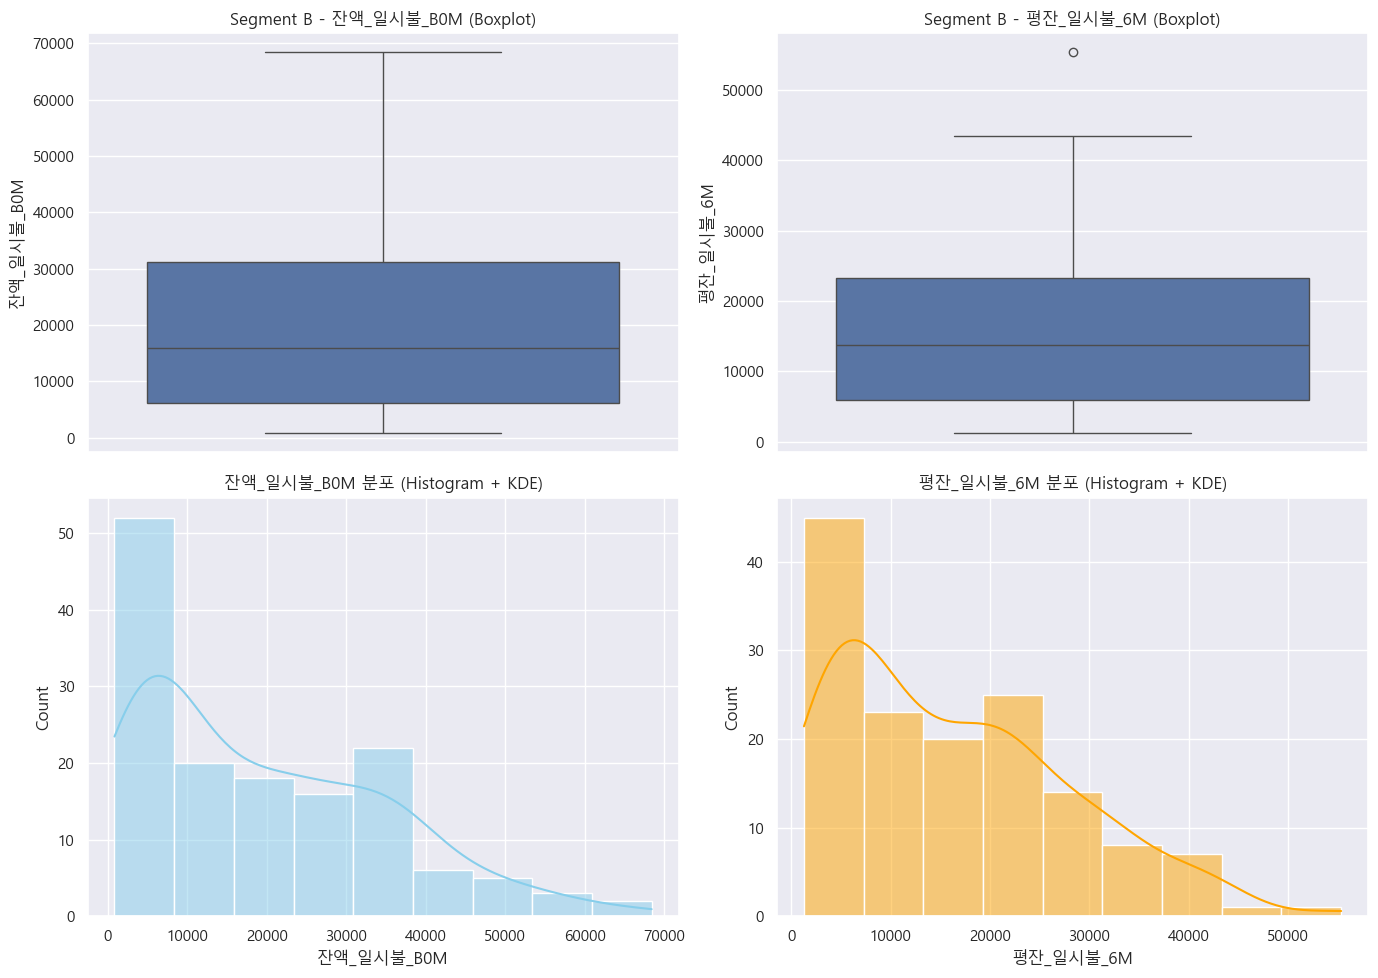

In [157]:
segB = train_df[train_df['Segment'] == 1]
cols = ['잔액_일시불_B0M', '평잔_일시불_6M']

print("Segment B 기술통계")
print(segB[cols].describe().round(2))

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

sns.boxplot(data=segB, y='잔액_일시불_B0M', ax=axes[0, 0])
axes[0, 0].set_title('Segment B - 잔액_일시불_B0M (Boxplot)')

sns.boxplot(data=segB, y='평잔_일시불_6M', ax=axes[0, 1])
axes[0, 1].set_title('Segment B - 평잔_일시불_6M (Boxplot)')

sns.histplot(segB['잔액_일시불_B0M'], kde=True, color='skyblue', ax=axes[1, 0])
axes[1, 0].set_title('잔액_일시불_B0M 분포 (Histogram + KDE)')

sns.histplot(segB['평잔_일시불_6M'], kde=True, color='orange', ax=axes[1, 1])
axes[1, 1].set_title('평잔_일시불_6M 분포 (Histogram + KDE)')

plt.tight_layout()
plt.show()

- 갯수가 144개로 다른 등급에 비해 현저히 수가 적다.
- B등급 역시 표준편차가 크고, 최대값이 평균에 비하여 매우 크다.

잔액_일시불_B0M:
- 이상치로 보이는 점은 보이지 않으나 최대값이 매우 크고 75% 값과 차이가 큼
- 분포가 오른쪽으로 꼬리가 긴형태
- 대부분의 값이 0~20000 사이에 집중되어 있음.
- 일부 고액 사용자가 존재함

평잔_일시불_6M
- 하나의 명백한 이상치(최대값보다 높은 점)가 존재
- 비슷하게 값들이 0~20000 구간에 많이 몰려 있음
- 역시 오른쪽 꼬리가 긴 형태

### C등급

Segment C 기술통계
       잔액_일시불_B0M  평잔_일시불_6M
count   127590.00  127590.00
mean     11505.37   14118.22
std      12500.46   13557.29
min          0.00       0.00
25%       2871.00    3825.00
50%       8019.50   10689.00
75%      16267.75   20869.50
max     222767.00  176861.00


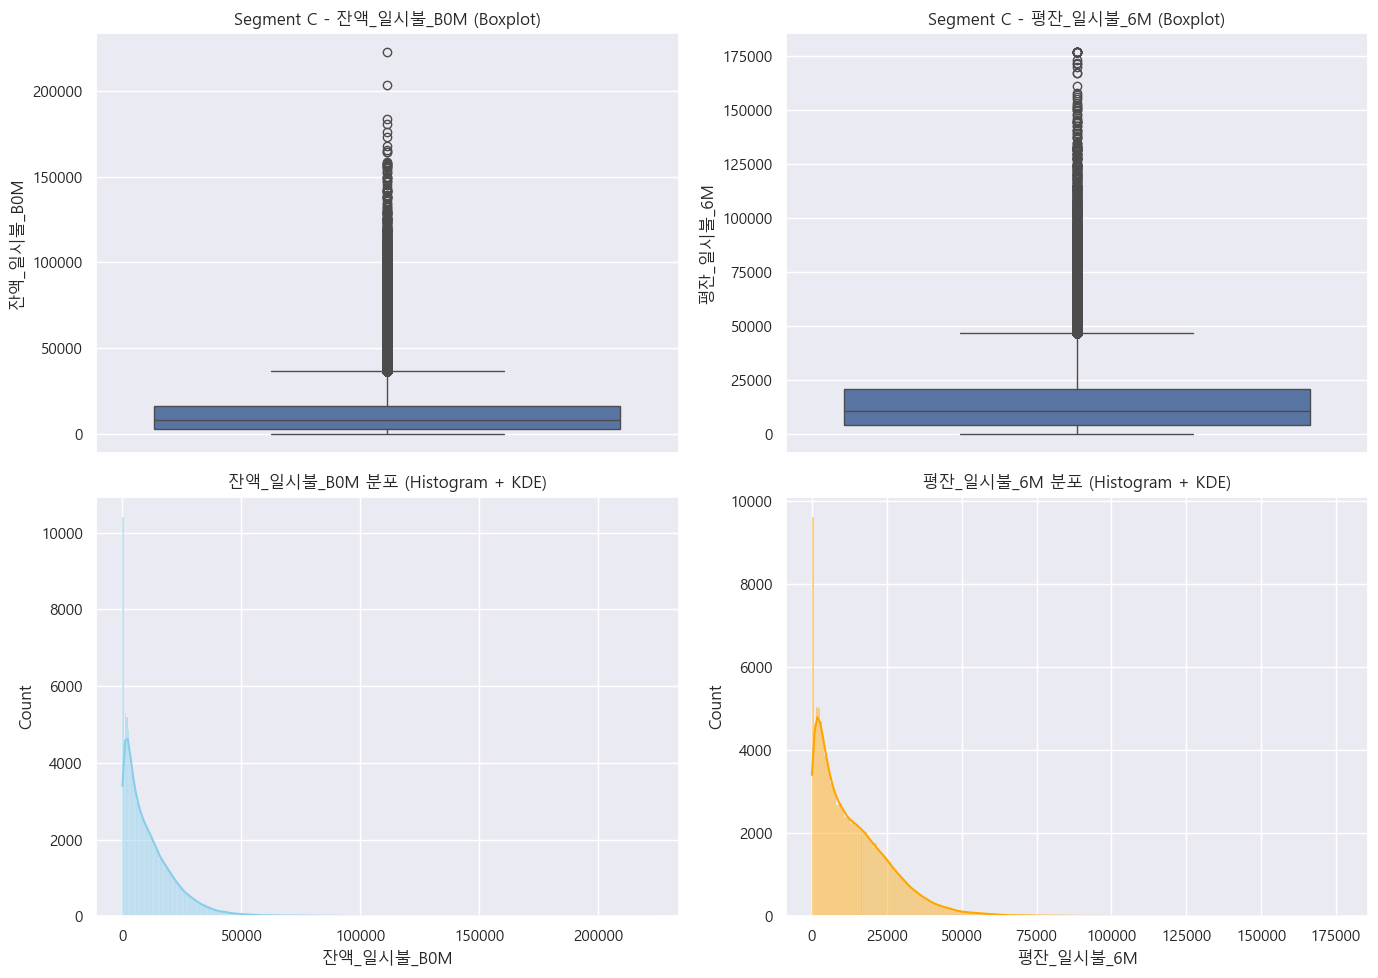

In [159]:
segC = train_df[train_df['Segment'] == 2]
cols = ['잔액_일시불_B0M', '평잔_일시불_6M']

print("Segment C 기술통계")
print(segC[cols].describe().round(2))

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

sns.boxplot(data=segC, y='잔액_일시불_B0M', ax=axes[0, 0])
axes[0, 0].set_title('Segment C - 잔액_일시불_B0M (Boxplot)')

sns.boxplot(data=segC, y='평잔_일시불_6M', ax=axes[0, 1])
axes[0, 1].set_title('Segment C - 평잔_일시불_6M (Boxplot)')

sns.histplot(segC['잔액_일시불_B0M'], kde=True, color='skyblue', ax=axes[1, 0])
axes[1, 0].set_title('잔액_일시불_B0M 분포 (Histogram + KDE)')

sns.histplot(segC['평잔_일시불_6M'], kde=True, color='orange', ax=axes[1, 1])
axes[1, 1].set_title('평잔_일시불_6M 분포 (Histogram + KDE)')

plt.tight_layout()
plt.show()

- 두 변수 모두 값의 범위가 매우 넓으며, 최대값이 평균보다 훨씬 크고, 75% 사분위수도 평균보다 낮은 점으로 보아 극단적으로 큰 값이 존재함을 알 수 있다.
- 두 변수 모두 박스 위 로 많은 이상치가 확인된다.
- 최대값이 매우 크고, 이상치들이 집중되어 있어 분포가 한쪽으로 치우친 오른쪽 꼬리 분포임을 알 수 있다.
- 두 변수 모두 0에 가까운 값에 데이터가 몰려있고 점점 값이 커질수록 빈도가 급격히 감소하는 형태를 보인다.

### D등급

Segment D 기술통계
       잔액_일시불_B0M  평잔_일시불_6M
count   349242.00  349242.00
mean      7208.86    9045.81
std       9193.19    9996.73
min          0.00       0.00
25%       1944.00    2660.00
50%       4760.00    6376.00
75%       9241.00   12221.00
max     196046.00  176861.00


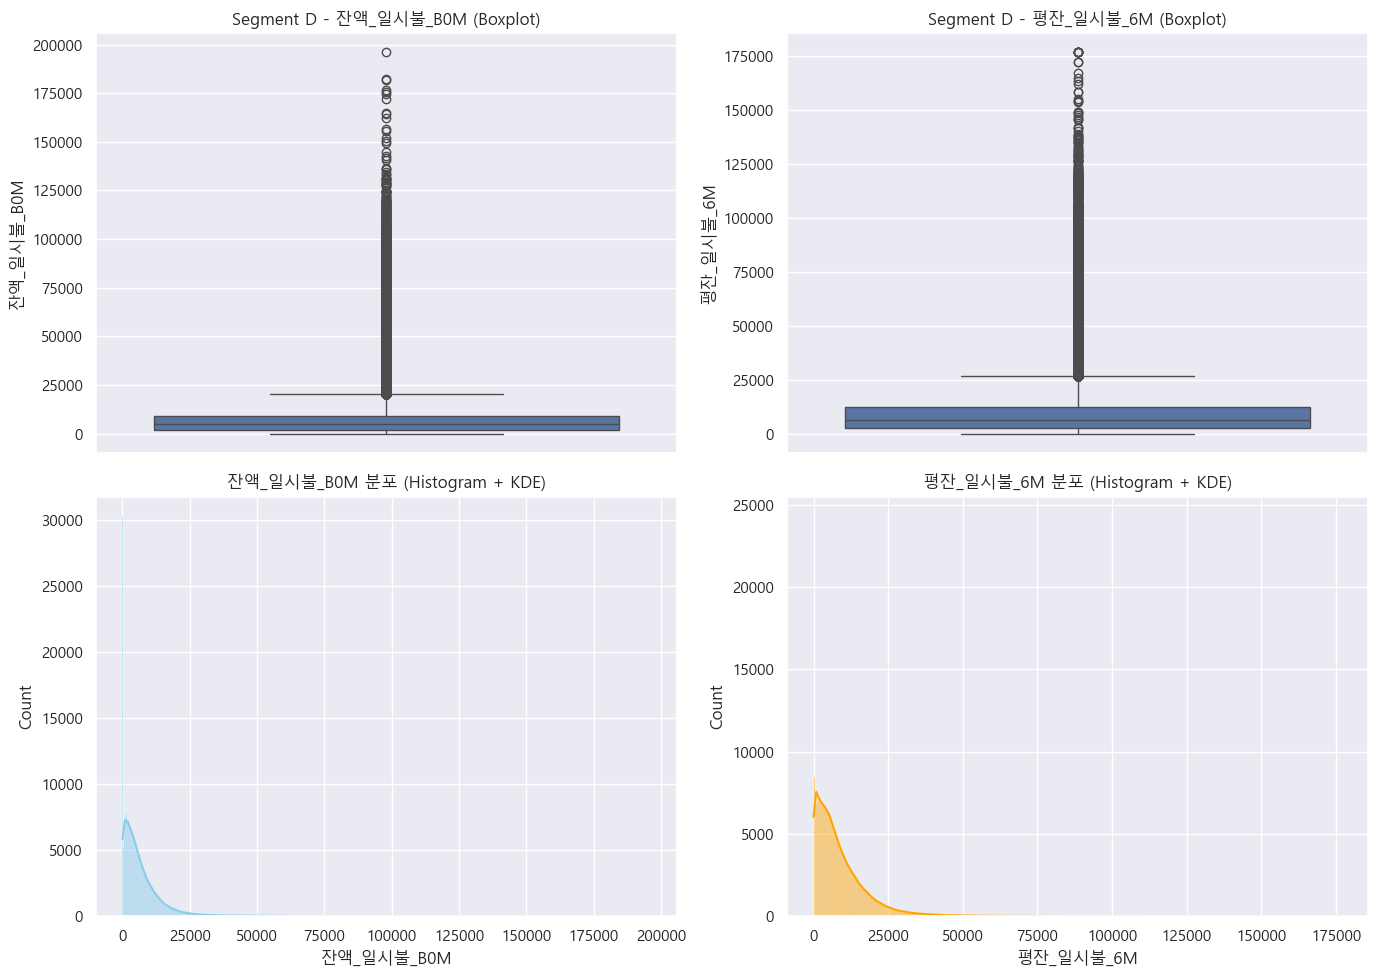

In [161]:
segD = train_df[train_df['Segment'] == 3]
cols = ['잔액_일시불_B0M', '평잔_일시불_6M']

print("Segment D 기술통계")
print(segD[cols].describe().round(2))

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

sns.boxplot(data=segD, y='잔액_일시불_B0M', ax=axes[0, 0])
axes[0, 0].set_title('Segment D - 잔액_일시불_B0M (Boxplot)')

sns.boxplot(data=segD, y='평잔_일시불_6M', ax=axes[0, 1])
axes[0, 1].set_title('Segment D - 평잔_일시불_6M (Boxplot)')

sns.histplot(segD['잔액_일시불_B0M'], kde=True, color='skyblue', ax=axes[1, 0])
axes[1, 0].set_title('잔액_일시불_B0M 분포 (Histogram + KDE)')

sns.histplot(segD['평잔_일시불_6M'], kde=True, color='orange', ax=axes[1, 1])
axes[1, 1].set_title('평잔_일시불_6M 분포 (Histogram + KDE)')

plt.tight_layout()
plt.show()

- 두 변수 모두 중앙값 대비 최대값이 매우 커서(잔액일시불 : 196,046, 평잔일시불 : 176,861), 극단적인 이상치가 많이 포함되어 있음이 보인다.
- 박스플롯 상자 내부는 상대적으로 좁지만, 위쪽에 수많은 이상치 점들이 뭉쳐 있는 모습입니다.
- 대부분 데이터는 낮은 값대에 집중되어 있고, 소수의 데이터가 매우 큰 값을 가진다.
- 두 변수 모두 오른쪽으로 꼬리가 긴 형태이다. 

### E등급

Segment E 기술통계
       잔액_일시불_B0M   평잔_일시불_6M
count  1922052.00  1922052.00
mean      2039.21     2640.09
std       4092.61     4766.98
min          0.00        0.00
25%          0.00       25.00
50%        802.00      985.00
75%       2637.00     3545.00
max     150595.00   166448.00


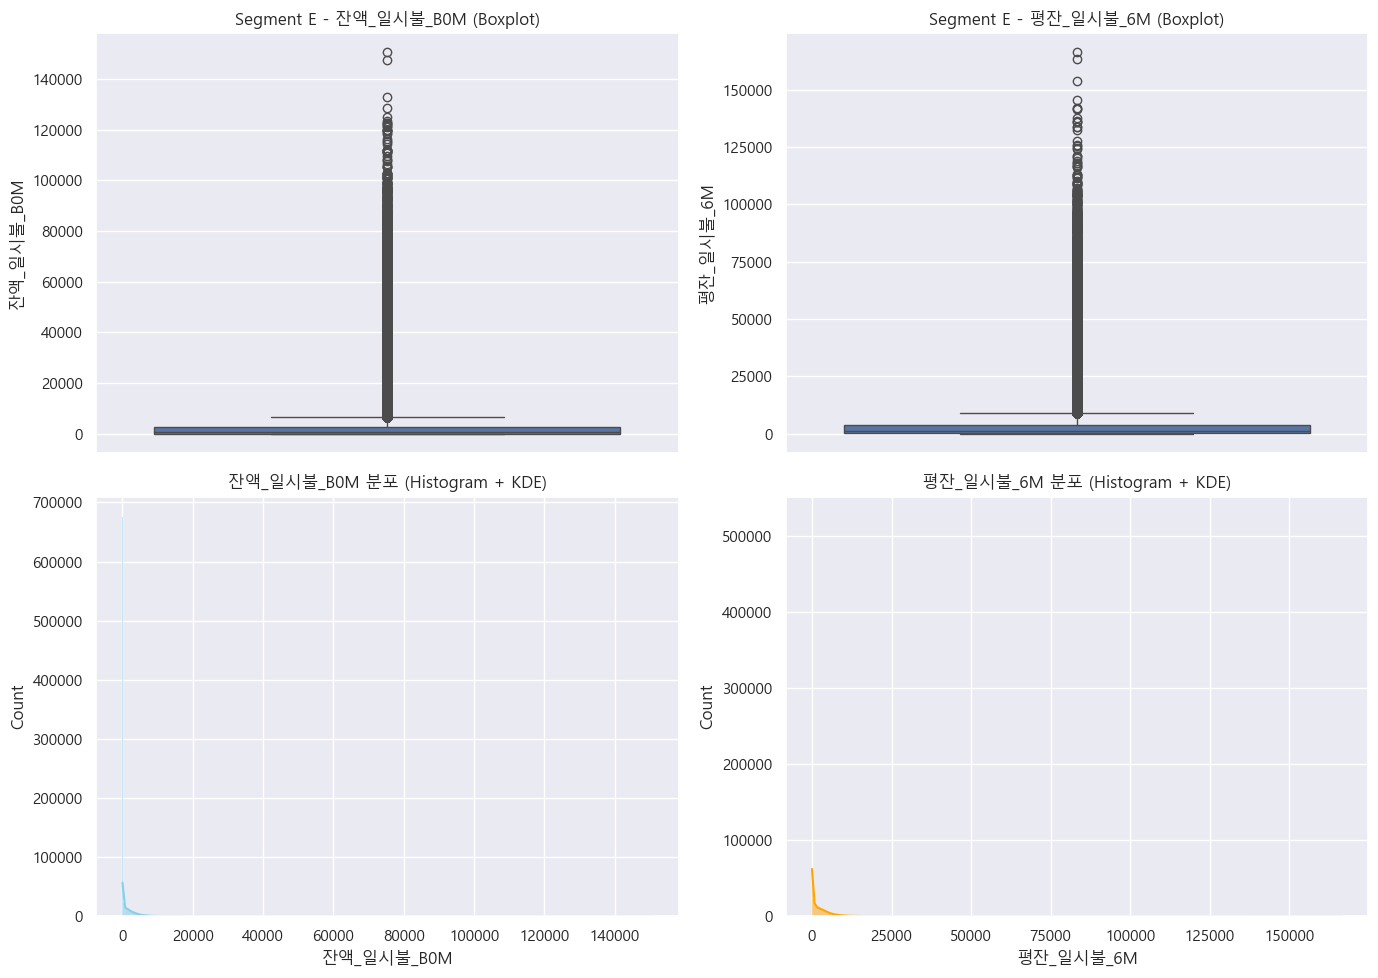

In [163]:
segE = train_df[train_df['Segment'] == 4]
cols = ['잔액_일시불_B0M', '평잔_일시불_6M']

print("Segment E 기술통계")
print(segE[cols].describe().round(2))

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

sns.boxplot(data=segE, y='잔액_일시불_B0M', ax=axes[0, 0])
axes[0, 0].set_title('Segment E - 잔액_일시불_B0M (Boxplot)')

sns.boxplot(data=segE, y='평잔_일시불_6M', ax=axes[0, 1])
axes[0, 1].set_title('Segment E - 평잔_일시불_6M (Boxplot)')

sns.histplot(segE['잔액_일시불_B0M'], kde=True, color='skyblue', ax=axes[1, 0])
axes[1, 0].set_title('잔액_일시불_B0M 분포 (Histogram + KDE)')

sns.histplot(segE['평잔_일시불_6M'], kde=True, color='orange', ax=axes[1, 1])
axes[1, 1].set_title('평잔_일시불_6M 분포 (Histogram + KDE)')

plt.tight_layout()
plt.show()

- 다른 컬럼에 비하여 월등히 많은 데이터 (1922052개)를 가지고 있다.
- 두 변수 모두 중앙값과 평균이 큰 차이를 보이며, 상위 극단값이 매우 많은 분포임을 알 수 있다.
- 박스플롯 상단에 많은 이상치가 확인되며, 값이 매우 크게 치우쳐 있다.
- 히스토그램은 극단적으로 치우쳐 있어 대부분의 값이 0~10,000 이하에 집중되어 있고 극소수의 매우 큰 값들이 있음을 알 수 있다.
- 중앙값이 낮고 25% 백분위수도 0인 것으로 보아, 적지 않은 데이터가 실제 값이 0임을 의미함

## 결과

In [285]:
cols = train_df[['잔액_일시불_B0M', '평잔_일시불_6M']]
mean = cols.mean()
std = cols.std()
median = cols.median()

print(f"평균:\n{mean}\n\n표준편차:\n{std}\n\n중앙값:{median}")

평균:
잔액_일시불_B0M    3303.328998
평잔_일시불_6M     4191.551862
dtype: float64

표준편차:
잔액_일시불_B0M    6427.956370
평잔_일시불_6M     7304.055577
dtype: float64

중앙값:잔액_일시불_B0M    1298.0
평잔_일시불_6M     1704.0
dtype: float64


- 표준편차가 평균의 거의 2배 정도로 매우 크다.
- 평균이 중앙값보다 2배 이상 크다.
- 작은 데이터가 큰 데이터보다 훨씬 많아 평균에 영향을 주었다.
- 데이터가 평균 근처에만 몰려 있지 않고, 아주 큰 값들이 포함되어 있다는 뜻이다.
- 즉, 극단적으로 큰 값들이 표준편차를 키운 경우이다.

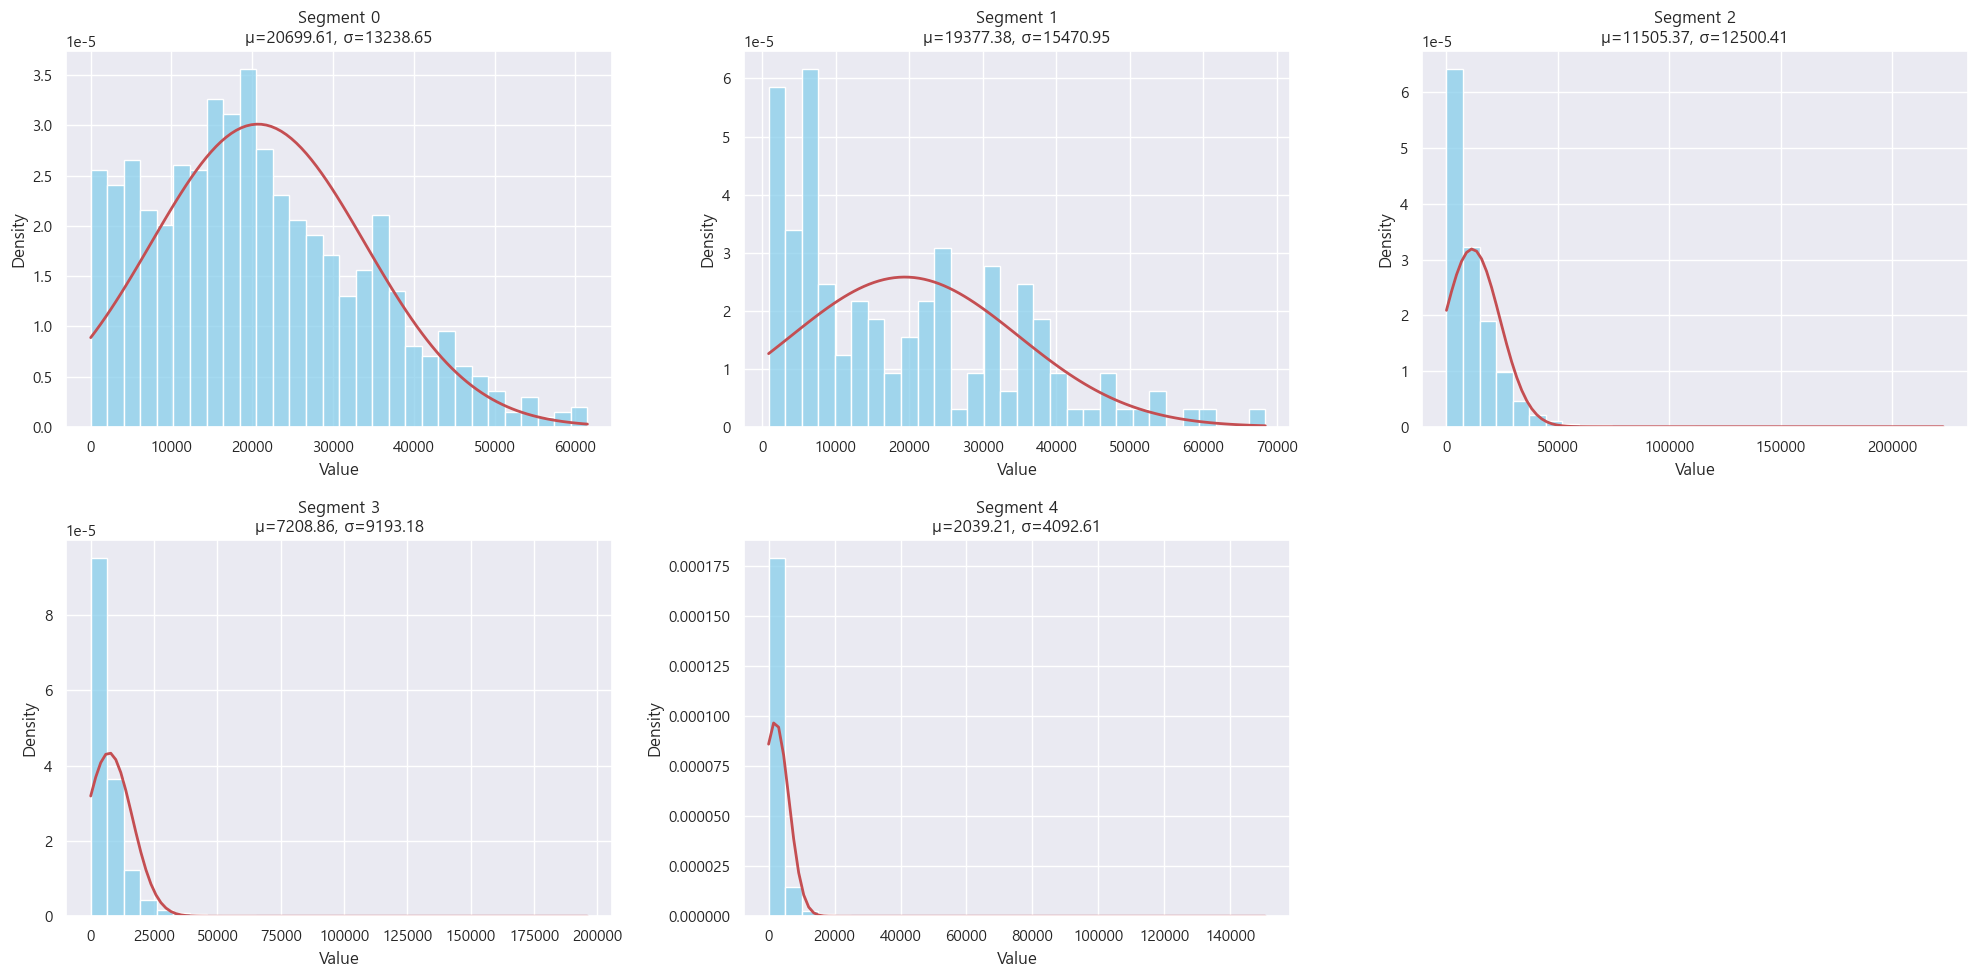

In [229]:
segments = [0, 1, 2, 3, 4]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, seg in enumerate(segments):
    subset = train_df[train_df['Segment'] == seg]['잔액_일시불_B0M'].dropna()

    sns.histplot(subset, bins=30, kde=False, stat='density', ax=axes[i], color='skyblue')

    mu, std = norm.fit(subset)
    x = np.linspace(subset.min(), subset.max(), 100)
    p = norm.pdf(x, mu, std)
    axes[i].plot(x, p, 'r', linewidth=2)

    axes[i].set_title(f'Segment {seg}\nμ={mu:.2f}, σ={std:.2f}')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

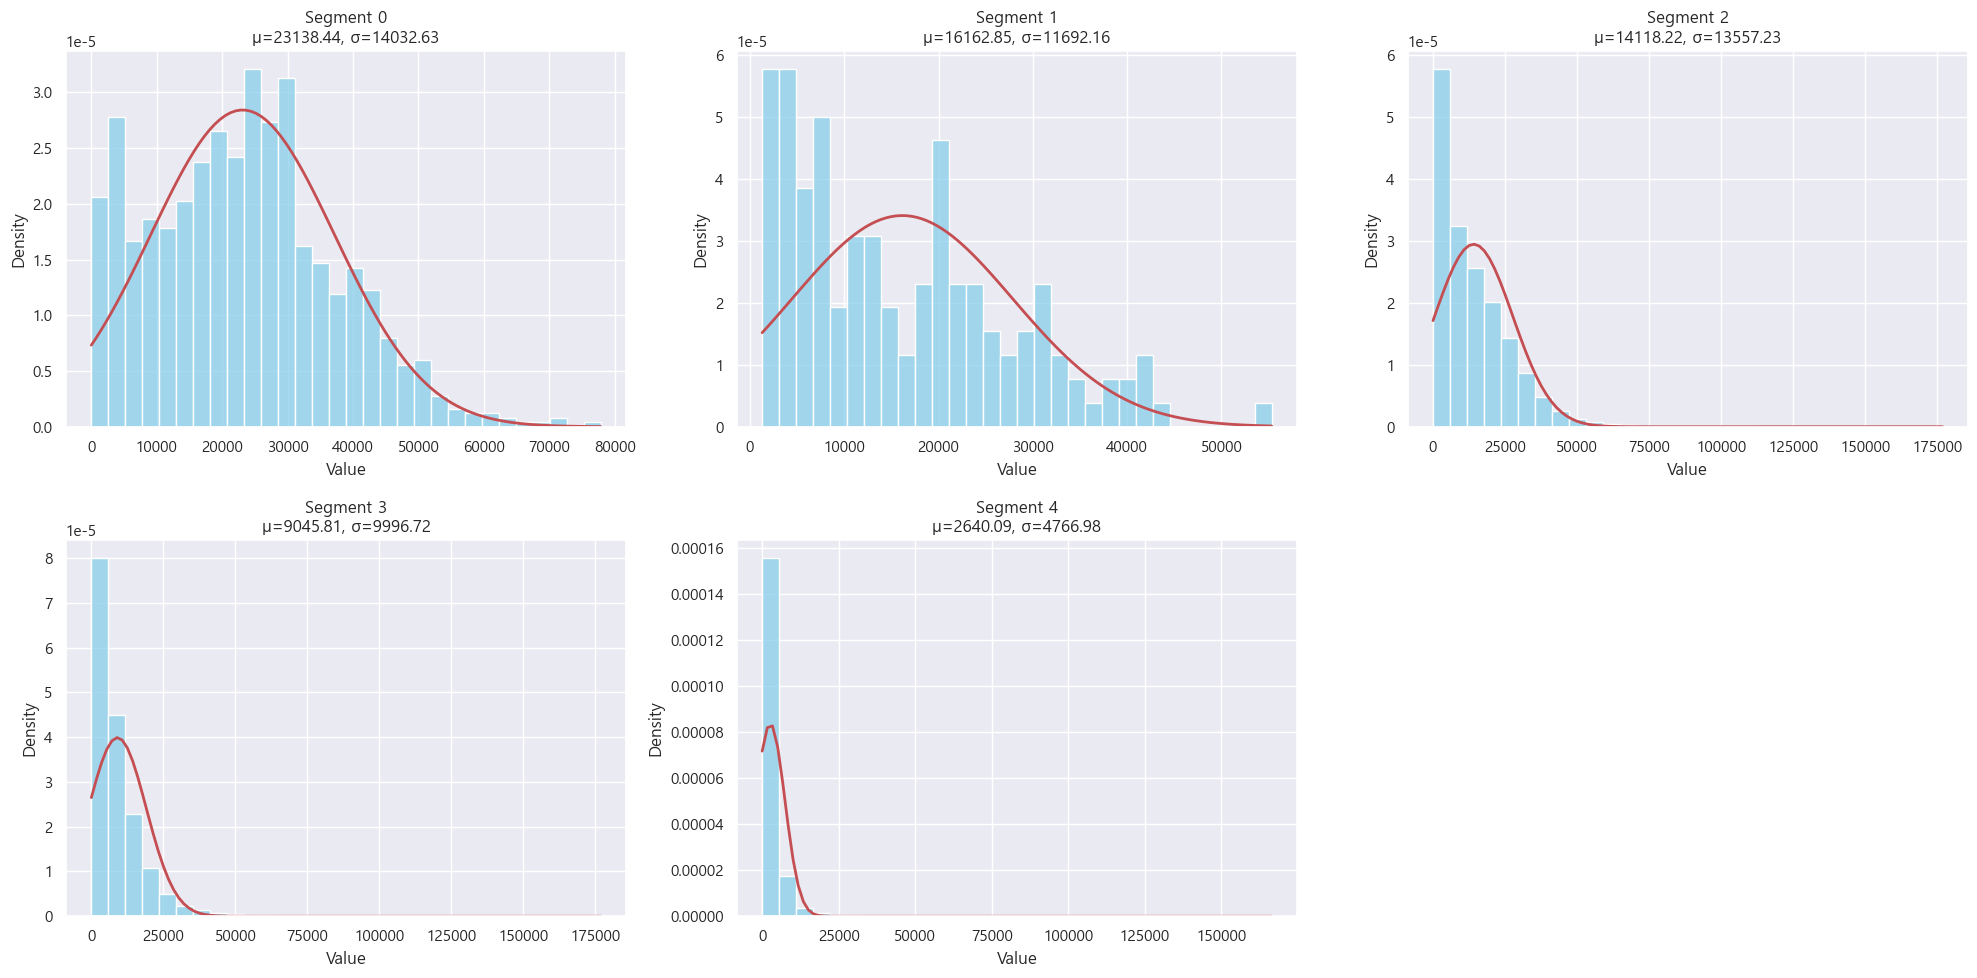

In [245]:
segments = [0, 1, 2, 3, 4]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, seg in enumerate(segments):
    subset = train_df[train_df['Segment'] == seg]['평잔_일시불_6M'].dropna()

    sns.histplot(subset, bins=30, kde=False, stat='density', ax=axes[i], color='skyblue')

    mu, std = norm.fit(subset)
    x = np.linspace(subset.min(), subset.max(), 100)
    p = norm.pdf(x, mu, std)
    axes[i].plot(x, p, 'r', linewidth=2)

    axes[i].set_title(f'Segment {seg}\nμ={mu:.2f}, σ={std:.2f}')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

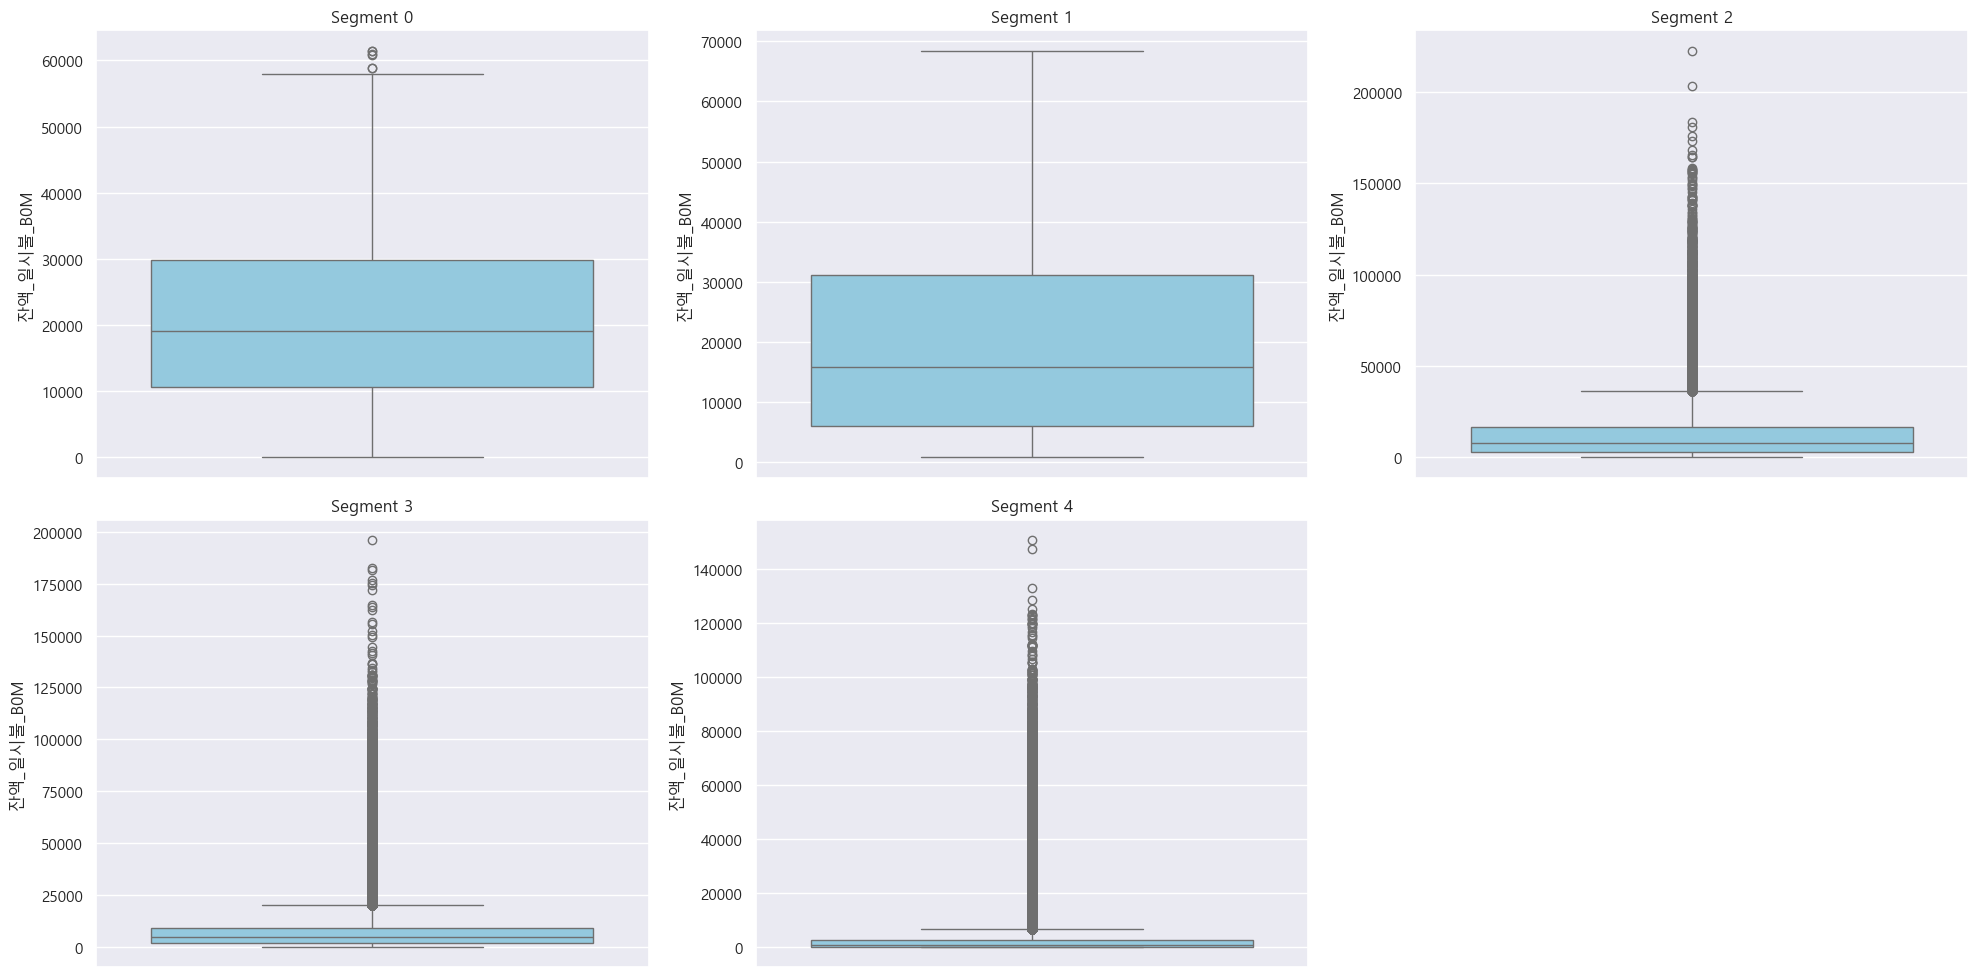

In [278]:
segments = [0, 1, 2, 3, 4]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, seg in enumerate(segments):
    subset = train_df[train_df['Segment'] == seg]['잔액_일시불_B0M'].dropna()

    sns.boxplot(y=subset, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Segment {seg}')
    axes[i].set_ylabel('잔액_일시불_B0M')
    axes[i].set_xlabel('')

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

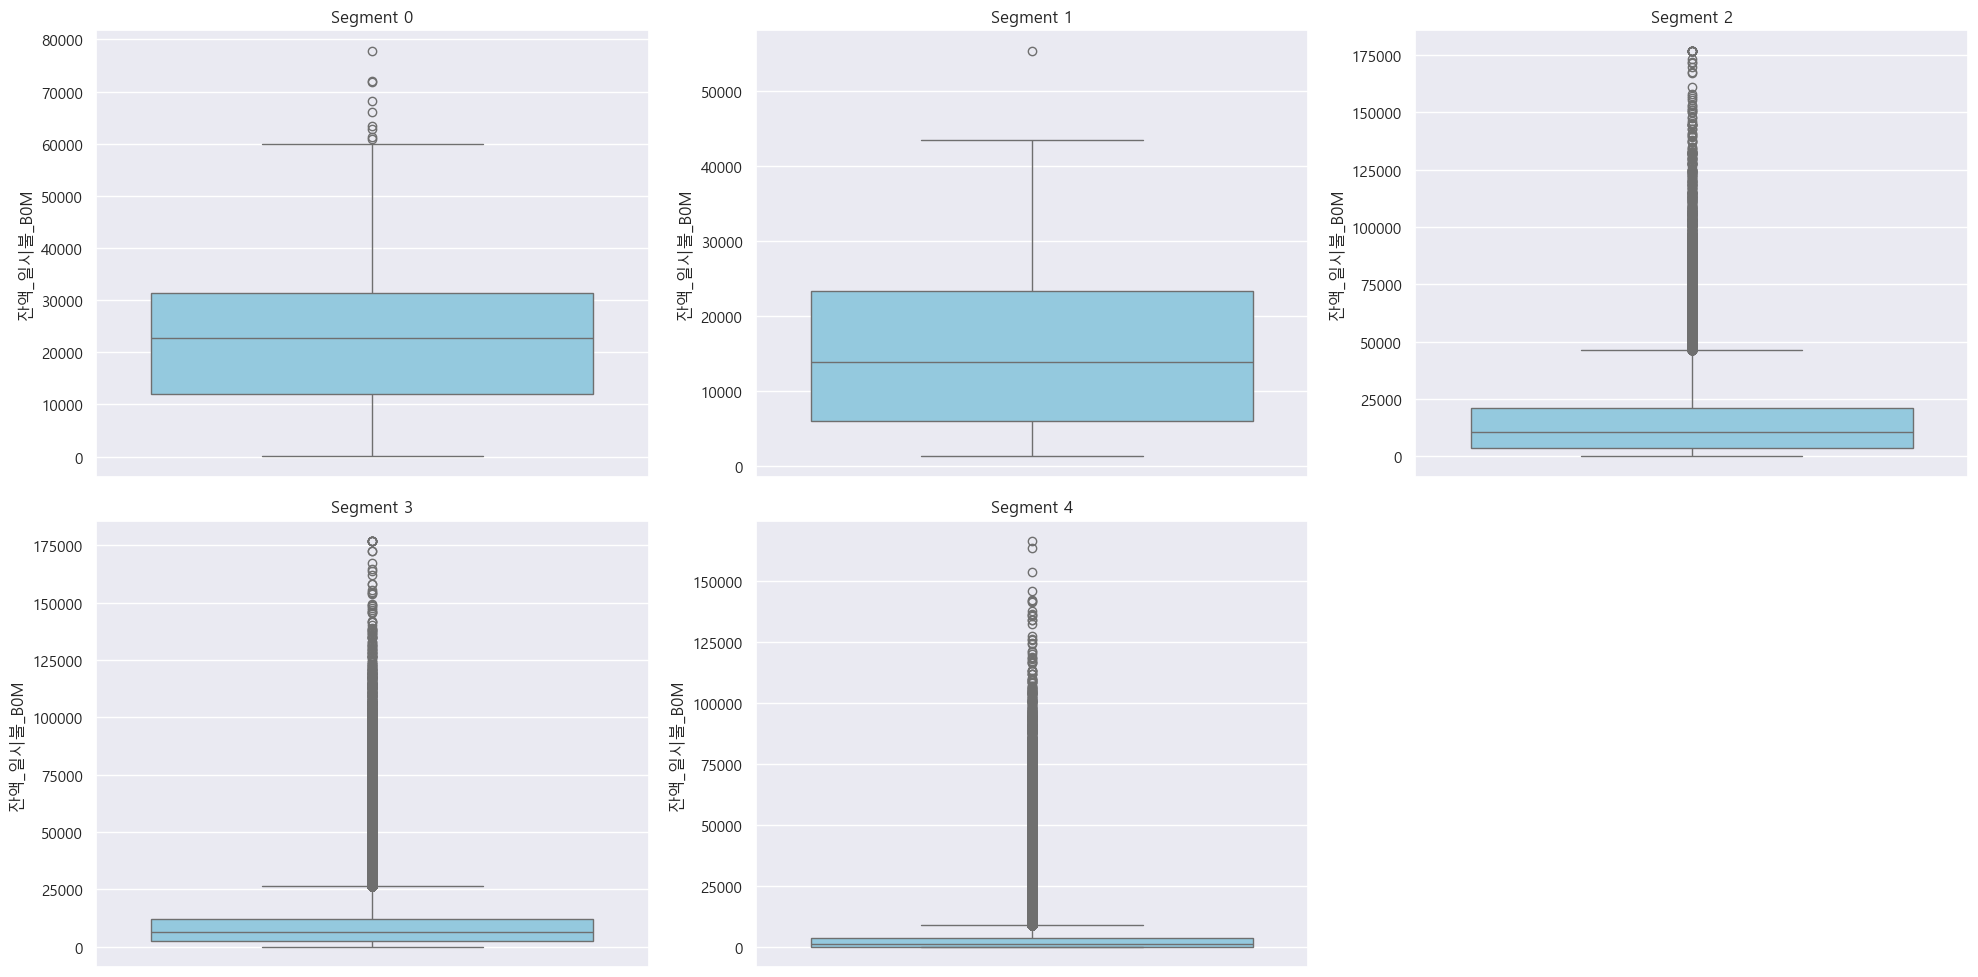

In [280]:
segments = [0, 1, 2, 3, 4]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, seg in enumerate(segments):
    subset = train_df[train_df['Segment'] == seg]['평잔_일시불_6M'].dropna()

    sns.boxplot(y=subset, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Segment {seg}')
    axes[i].set_ylabel('잔액_일시불_B0M')
    axes[i].set_xlabel('')

# 마지막 빈 서브플롯 제거
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

C, D, E 등급에서 A와 B 등급보다 이상치가 더 많이 나타난 이유:
- 일부 고액 사용자의 존재로 인해 분포의 상단이 길게 늘어져 있다.
- 소액 사용자들이 밀집되어 있어, 전체적으로 분포의 비대칭성이 커졌다.
- 다른 변수 없이 단일 컬럼만으로는 원인 확인 불가